<a href="https://colab.research.google.com/github/gkmfrombs/Indian-Labor-Force-Education/blob/main/02_EDA_%26_Visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📊 Exploratory Data Analysis: Indian Labor Force & Education**

**Dataset Source:** Periodic Labour Force Survey (PLFS) via NDAP (NITI Aayog)

**Core Objective:** Analyze how specific educational attainment levels impact the Unemployment Rate (UR) and Worker Population Ratio (WPR) across different Indian states and rural/urban demographics.

**🎯 Goals for this Notebook:**

Data Ingestion: Load the raw PLFS dataset and examine its initial structure and data types.

Data Cleaning: Handle any missing values, standardize column names, and address geographic edge cases (e.g., Chandigarh's purely urban classification).

Exploratory Visualizations: Uncover initial trends and correlations between education levels and employability to inform our future predictive models.

---

---
### ***[click here for the data](https://drive.google.com/file/d/1wk6Kkfatcx1KOylQfWHaJ68HQqJkEg8Y/view?usp=sharing)***

---



### Loading The Data
Necessary Libraries & Imports

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats



import warnings
warnings.filterwarnings('ignore')





In [ ]:
df = pd.read_csv('/content/PLFS.csv')

### **EDA**

In [ ]:
print(df.columns)
df.shape

Index(['Country', 'State', 'Year', 'Type Of Areas', 'Gender',
       'Education Level',
       'Labor Force Participation Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1',
       'Working Population Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1',
       'Unemployment Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1'],
      dtype='object')


(22650, 9)

In [ ]:
df.head()

,Country,State,Year,Type Of Areas,Gender,Education Level,"Labor Force Participation Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1","Working Population Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1","Unemployment Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1"
0,India,Andaman and Nicobar Islands,"Year (Jul - Jun), 2023",Rural,Male,Not Literate,76.7,76.7,0.0
1,India,Andaman and Nicobar Islands,"Year (Jul - Jun), 2023",Rural,Male,Literate & Upto Primary,87.0,87.0,0.0
2,India,Andaman and Nicobar Islands,"Year (Jul - Jun), 2023",Rural,Male,Middle,89.7,88.0,1.9
3,India,Andaman and Nicobar Islands,"Year (Jul - Jun), 2023",Rural,Male,Secondary,58.8,58.8,0.0
4,India,Andaman and Nicobar Islands,"Year (Jul - Jun), 2023",Rural,Male,Higher Secondary,78.3,71.3,9.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22650 entries, 0 to 22649
Data columns (total 9 columns):
 #   Column                                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                                     --------------  -----  
 0   Country                                                                                                                                    22650 non-null  object 
 1   State                                                                                                                                      22650 non-null  object 
 2   Year                                                                                                                                       22650 non-null  object 
 3   Type Of Areas                                  

In [ ]:
print("missing values")
print("=================================")
df.isnull().sum()

missing values


,0
Country,0
State,0
Year,0
Type Of Areas,0
Gender,0
Education Level,0
"Labor Force Participation Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1",30
"Working Population Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1",30
"Unemployment Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1",30


In [ ]:
df.describe()

,"Labor Force Participation Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1","Working Population Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1","Unemployment Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1"
count,22620.000000,22620.000000,22620.000000
mean,56.570723,51.294892,9.059253
std,24.406334,23.137787,12.121258
min,0.000000,0.000000,0.000000
25%,39.475000,34.700000,1.000000
50%,58.700000,52.850000,5.200000
75%,75.800000,68.900000,12.200000
max,100.000000,100.000000,100.000000


In [ ]:
df.describe(include='object')

,Country,State,Year,Type Of Areas,Gender,Education Level
count,22650,22650,22650,22650,22650,22650
unique,1,36,7,3,3,10
top,India,Andaman and Nicobar Islands,"Year (Jul - Jun), 2023",Rural,Male,Not Literate
freq,22650,630,3240,7560,7560,2265


In [ ]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"Unique values and their value counts in {col}:")
    print(df[col].unique(),df[col].value_counts())


Unique values and their value counts in Country:
['India'] Country
India    22650
Name: count, dtype: int64
Unique values and their value counts in State:
['Andaman and Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Ladakh' 'Lakshadweep' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana'
 'The Dadra and Nagar Haveli and Daman and Diu' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal'] State
Andaman and Nicobar Islands                     630
Andhra Pradesh                                  630
Arunachal Pradesh                               630
Assam                                           630
Bihar                                           630
Chandigarh                                      630
Chhattisgarh              

In [ ]:
df.columns

Index(['Country', 'State', 'Year', 'Type Of Areas', 'Gender',
       'Education Level',
       'Labor Force Participation Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1',
       'Working Population Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1',
       'Unemployment Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1'],
      dtype='object')

In [ ]:

# Renaming the columns to something manageable
rename_dict = {
    'Type Of Areas': 'Area_Type',
    'Education Level': 'Education_Level',
    'Labor Force Participation Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1': 'LFPR',
    'Working Population Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1': 'WPR',
    'Unemployment Rate According To Usual Status Based On Different General Education Level (UOM:%(Percentage)), Scaling Factor:1': 'UR'
}
df = df.rename(columns=rename_dict)
df.columns

Index(['Country', 'State', 'Year', 'Area_Type', 'Gender', 'Education_Level',
       'LFPR', 'WPR', 'UR'],
      dtype='object')

In [ ]:
# list of numerical variables

num_vars = [var for var in df.columns if df[var].dtypes != 'O']
print('Number of numerical variables: ', num_vars, len(num_vars))

Number of numerical variables:  ['LFPR', 'WPR', 'UR'] 3


In [ ]:
#list of discrete variables

discrete_vars = [var for var in num_vars if len(df[var].unique())<20 ]
print('Number of discrete variables: ', discrete_vars, len(discrete_vars))

Number of discrete variables:  [] 0


In [ ]:
# list of continuous variables

cont_vars = [var for var in num_vars if var not in discrete_vars]
print('Number of continuous variables: ', cont_vars, len(cont_vars))

Number of continuous variables:  ['LFPR', 'WPR', 'UR'] 3


In [ ]:
### Categorical variables

cat_vars = [var for var in df.columns if df[var].dtypes=='O']
print('Number of categorical variables: ', cat_vars, len(cat_vars))

Number of categorical variables:  ['Country', 'State', 'Year', 'Area_Type', 'Gender', 'Education_Level'] 6


In [ ]:
def missing_percentage(df):
    """This function takes a DataFrame(df) as input and returns two columns, total missing values and total missing values percentage"""
    ## the two following line may seem complicated but its actually very simple.
    total = df.isnull().sum().sort_values(ascending = False)[df.isnull().sum().sort_values(ascending = False) != 0]
    percent = round(df.isnull().sum().sort_values(ascending = False)/len(df)*100,2)[round(df.isnull().sum().sort_values(ascending = False)/len(df)*100,2) != 0]
    return pd.concat([total, percent], axis=1, keys=['Total','Percent'])
missing_percentage(df)

,Total,Percent
WPR,30,0.13
LFPR,30,0.13
UR,30,0.13


### **Data Visualization**

In [ ]:
# defining customised plots to see distribution, probability and boxplot

def diagnostic_plots(df, variable):
    # function takes a dataframe (df) and
    # the variable of interest as arguments

    # define figure size
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.distplot(df[variable], bins=30)
    plt.title('Histogram')

    # Q-Q plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

Checking outliers in continuous variables (Visualisation)

data column----> LFPR


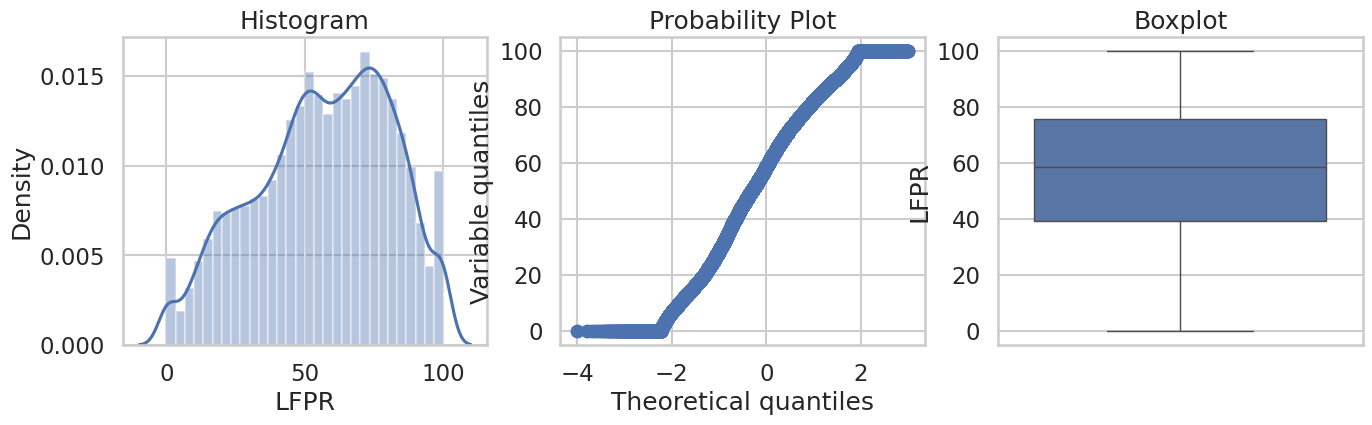

data column----> WPR


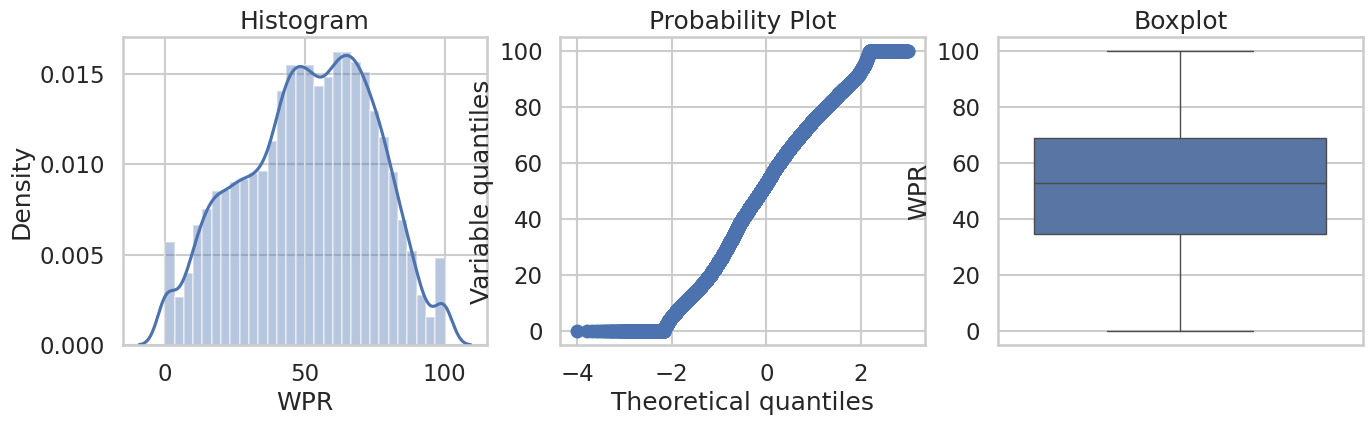

data column----> UR


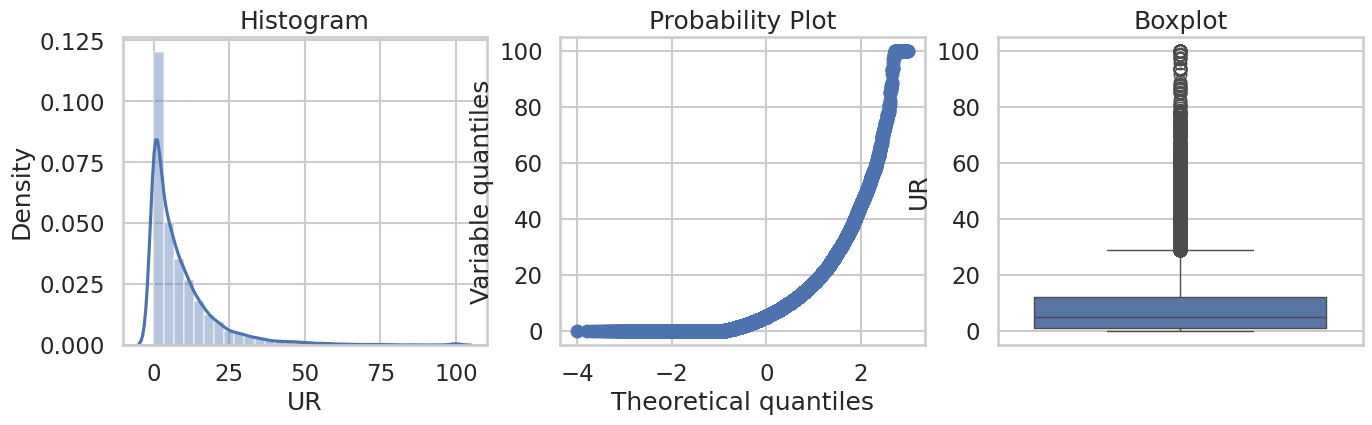

In [ ]:
for var in cont_vars:
    print("data column---->", var)
    diagnostic_plots(df, var)
    # print("Test", var)
    # diagnostic_plots(test, var)

In [ ]:
# defining outlier function to find outliers
def outlier_function(df, col_name):
    ''' this function detects first and third quartile and interquartile range for a given column of a dataframe
    then calculates upper and lower limits to determine outliers conservatively
    returns the number of lower and uper limit and number of outliers respectively
    '''
    first_quartile = np.percentile(np.array(df[col_name].tolist()), 25)
    third_quartile = np.percentile(np.array(df[col_name].tolist()), 75)
    IQR = third_quartile - first_quartile

    upper_limit = third_quartile+(1.5*IQR)
    lower_limit = first_quartile-(1.5*IQR)
    outlier_count = 0

    for value in df[col_name].tolist():
        if (value < lower_limit) | (value > upper_limit):
            outlier_count +=1
    return lower_limit, upper_limit, outlier_count

In [ ]:
# finding outliers in data
# loop through all columns to see if there are any outliers

outlier_columns=[]
for column in cont_vars:
    if outlier_function(df, column)[2] > 0:
        outlier_columns.append(column)
        print( "There are {} outliers in {}".format(outlier_function(df, column)[2], column))
        print("Lower limit is {} & Upper limit is {} in {}".format(outlier_function(df, column)[0],
                                                                    outlier_function(df, column)[1] ,column))
        print('\n')
print(outlier_columns)

[]


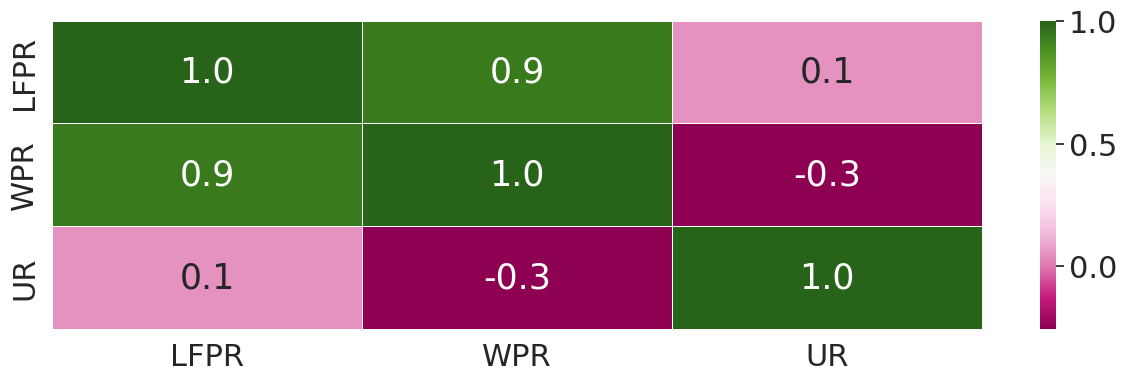

In [ ]:
correlation_of_data=df.corr(numeric_only=True)
sns.set(font_scale=2)
plt.figure(figsize = (15,4))
ax = sns.heatmap(correlation_of_data, annot=True,annot_kws={"size": 25},fmt='.1f',cmap='PiYG', linewidths=.5)

In [ ]:
corr_dict=correlation_of_data['UR'].sort_values(ascending=False).to_dict()
important_columns=[]
for key,value in corr_dict.items():
    if ((value>0.1) & (value<0.8)) | (value<=-0.1):
        important_columns.append(key)
important_columns

['WPR']

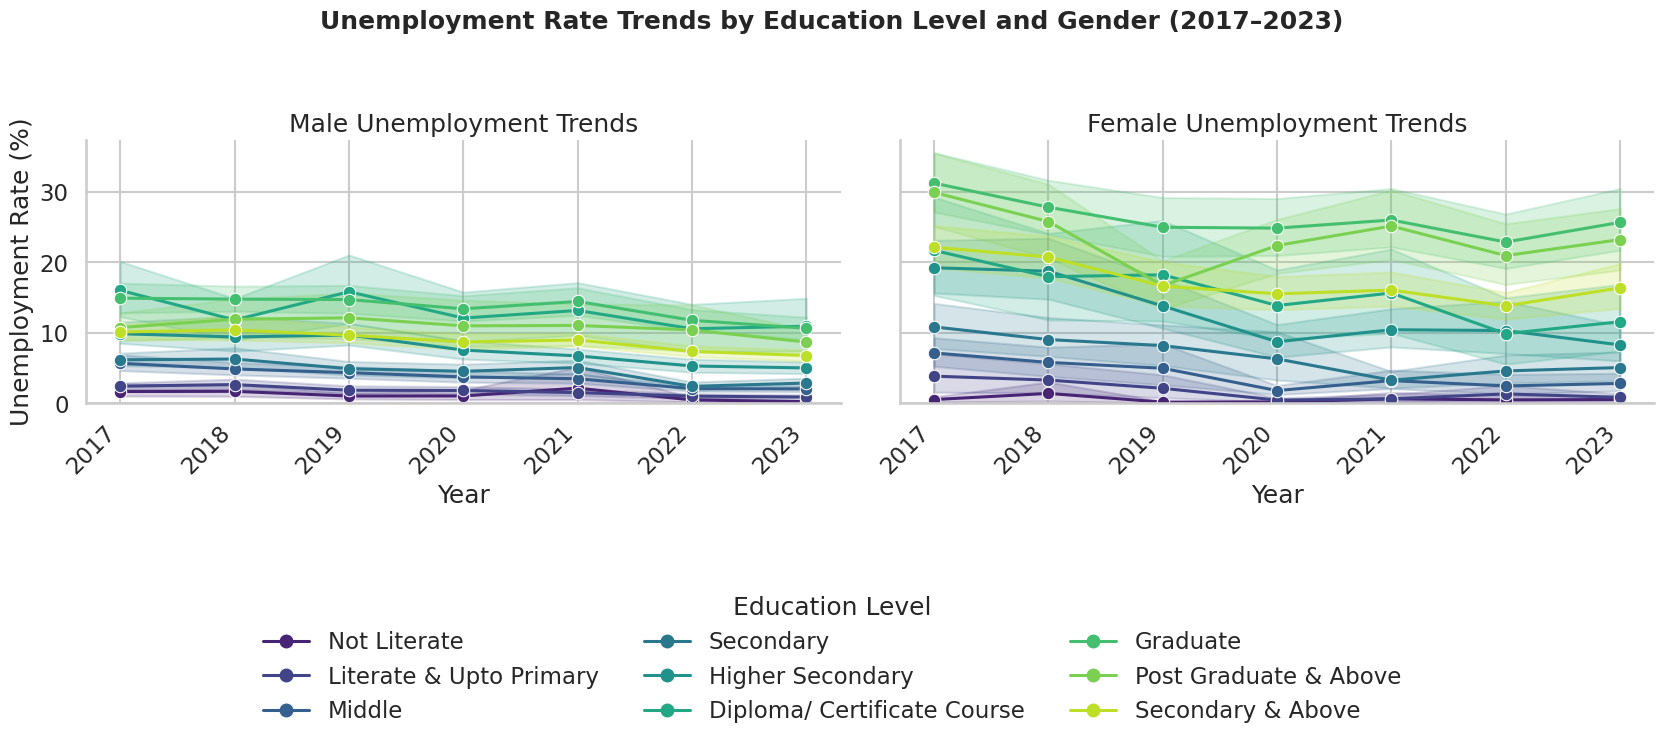

In [ ]:
# Filter the dataset
df_filtered = df[
    (df['Education_Level'] != 'All') &
    (df['Gender'] != 'Persons') &
    (df['Area_Type'] != 'Rural + Urban')
].copy()

# Extract numeric year
df_filtered['Year_Numeric'] = df_filtered['Year'].str.extract(r'(\d{4})').astype(int)

# Create the plot
sns.set(style="whitegrid", context="talk")  # cleaner style and larger labels

g = sns.relplot(
    data=df_filtered,
    x='Year_Numeric',
    y='UR',
    hue='Education_Level',
    col='Gender',
    kind='line',
    height=5,
    aspect=1.3,
    palette='viridis',
    marker='o',
    linewidth=2.2,
    facet_kws={'sharey': True, 'sharex': True}  # consistent scales across facets
)

# Axis labels and titles
g.set_axis_labels("Year", "Unemployment Rate (%)")
g.set_titles("{col_name} Unemployment Trends")  # cleaner facet titles
g.set(ylim=(0, None))  # start y-axis at 0 for clarity

# Rotate x-axis labels
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

# Adjust legend placement using Matplotlib API
handles, labels = g._legend.legend_handles, [t.get_text() for t in g._legend.texts]
g._legend.remove()  # remove seaborn's default legend
g.fig.legend(
    handles,
    labels,
    title="Education Level",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,   # spread across 3 columns
    frameon=False
)

# Main title
g.fig.suptitle(
    "Unemployment Rate Trends by Education Level and Gender (2017–2023)",
    y=1.05,
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

To provide clearer insights and address the clutter in previous visualizations, the following plots offer a refined view of the data. We'll focus on the distribution of Unemployment Rate (UR) and the average Working Population Ratio (WPR) across various educational levels and genders.

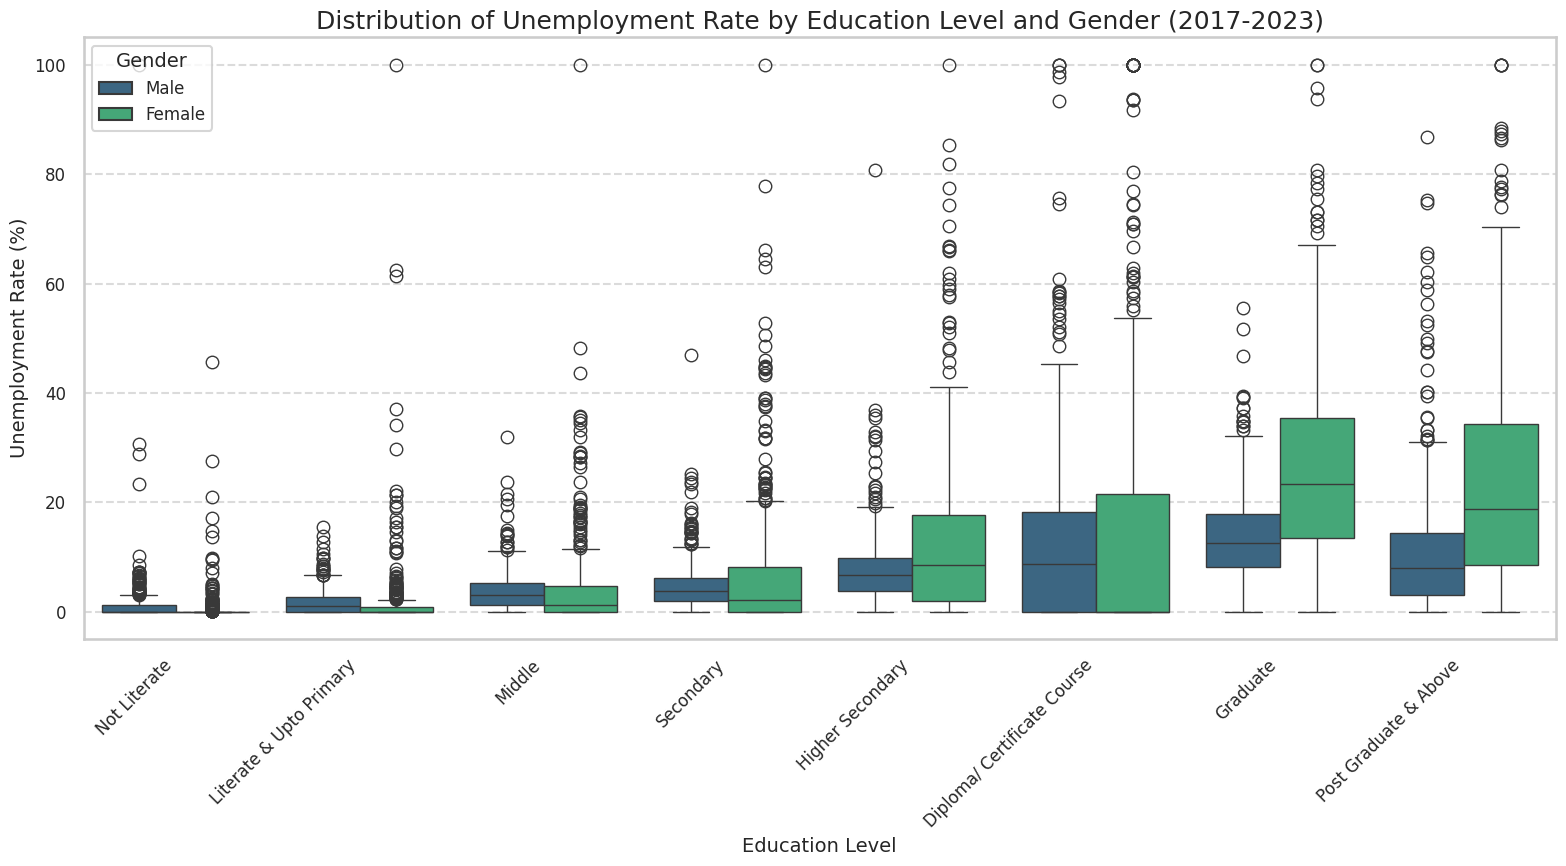

In [ ]:
# Define a custom order for Education Level for better readability
education_order = [
    'Not Literate',
    'Literate & Upto Primary',
    'Middle',
    'Secondary',
    'Higher Secondary',
    'Diploma/ Certificate Course',
    'Graduate',
    'Post Graduate & Above'
]

plt.figure(figsize=(16, 9)) # Adjust figure size for better display

# Create a box plot to show the distribution of Unemployment Rate
sns.boxplot(
    data=df_filtered,
    x='Education_Level',
    y='UR',
    hue='Gender',
    order=education_order,
    palette='viridis'
)

plt.title('Distribution of Unemployment Rate by Education Level and Gender (2017-2023)', fontsize=18)
plt.xlabel('Education Level', fontsize=14)
plt.ylabel('Unemployment Rate (%)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12) # Rotate and align labels
plt.yticks(fontsize=12)
plt.legend(title='Gender', fontsize=12, title_fontsize=14, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

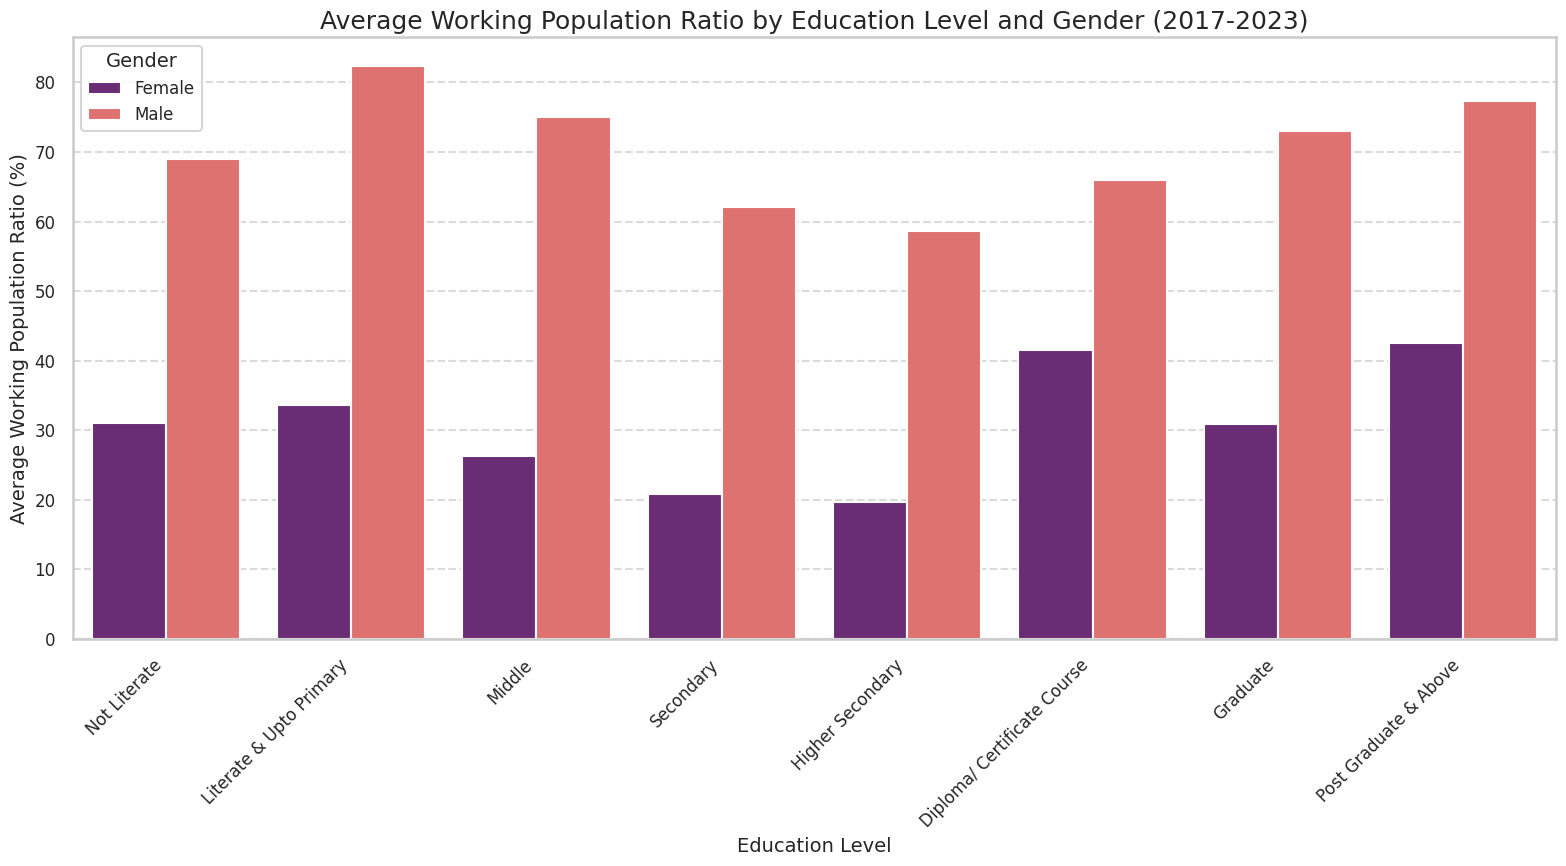

In [ ]:
# Calculate the average Working Population Ratio (WPR) by Education Level and Gender
avg_wpr = df_filtered.groupby(['Education_Level', 'Gender'])['WPR'].mean().reset_index()

plt.figure(figsize=(16, 9)) # Adjust figure size

# Create a bar plot to show the average Working Population Ratio
sns.barplot(
    data=avg_wpr,
    x='Education_Level',
    y='WPR',
    hue='Gender',
    order=education_order,
    palette='magma'
)

plt.title('Average Working Population Ratio by Education Level and Gender (2017-2023)', fontsize=18)
plt.xlabel('Education Level', fontsize=14)
plt.ylabel('Average Working Population Ratio (%)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Gender', fontsize=12, title_fontsize=14, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Key Insights from the Data Visualizations

**1. Unemployment Rate Trends Over Time (2017-2023):**
*   **Higher Education, Lower Unemployment (Generally):** People with 'Post Graduate & Above' and 'Graduate' degrees generally experienced lower unemployment rates compared to those with 'Not Literate' or 'Literate & Upto Primary' education levels. This trend is consistent for both males and females.
*   **Impact of Secondary Education:** Individuals with 'Secondary' and 'Higher Secondary' education levels often show noticeable fluctuations in unemployment, sometimes spiking higher than those with less education, particularly for males.
*   **Gender Gap:** Across most education levels, female unemployment rates tend to be higher than male unemployment rates. This gap is quite pronounced in many cases.
*   **Yearly Fluctuations:** There's an overall trend of varying unemployment across the years, likely influenced by economic conditions, but the relative differences between education levels and genders generally persist.

**2. Distribution of Unemployment Rate by Education Level and Gender:**
*   **Education is Key to Stability:** The box plots clearly show that as education levels increase (especially from 'Graduate' onwards), the median unemployment rate tends to decrease, and the spread (interquartile range) of unemployment rates also becomes narrower. This suggests more stable employment opportunities for highly educated individuals.
*   **Vulnerability at Lower Education:** Individuals who are 'Not Literate' or 'Literate & Upto Primary' face not only higher unemployment but also a wider range of potential unemployment rates, indicating more volatile employment situations.
*   **Female Disadvantage:** The female unemployment rate boxes are generally positioned higher on the Y-axis and often show a larger spread compared to males, particularly at lower and mid-level education stages. This reinforces the challenge women face in the job market.

**3. Average Working Population Ratio (WPR) by Education Level and Gender:**
*   **WPR and Education:** The WPR generally increases with higher education levels. This indicates that a greater proportion of highly educated individuals are actively working or available for work.
*   **Significant Gender Divide:** There is a very clear and substantial gap in WPR between males and females across **all** education levels. Males consistently have a much higher WPR than females. This suggests that a smaller proportion of the female population, regardless of their education, is participating in the workforce compared to males.
*   **Highest WPR:** Males with 'Literate & Upto Primary', 'Middle', or 'Secondary' education often show the highest WPR, indicating strong workforce participation at these levels. For females, WPR generally peaks at 'Graduate' and 'Post Graduate & Above', but even then, it's significantly lower than male WPR at any education level.

**In a nutshell:** Education generally leads to better employment outcomes (lower unemployment, higher workforce participation). However, a persistent gender gap exists, with women facing higher unemployment and lower workforce participation rates than men across almost all education levels in India.